In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
from sklearn.metrics import root_mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor
import seaborn as sns

In [2]:
msoa_gdf = gpd.read_file('../data/raw/MSOA_(2021)_EW_BSC_V3_to_Rural_Urban_Classification.geojson') \
    .to_crs(27700)

In [3]:
msoa_population = pd.read_csv('../data/raw/msoa_population.csv')

## Models

In [20]:
def crime_counts_per_month(start_date='2010-12', end_date='2026-04'):
    """
    Get crime counts per MSOA per month
    """

    dfs = []
    months = pd.date_range(start_date, end_date, freq="MS").strftime("%Y-%m").tolist()
    for month in months:
        street = pd.read_parquet(f'../data/processed/2. msoa/{month}-street.parquet', engine='pyarrow')

        street_grouped = street.groupby('MSOA21CD')['Crime ID']

        unique_ids = street_grouped.nunique()
        total_rows = street_grouped.size()
        blank_ids = total_rows - street_grouped.count()

        df = pd.concat([unique_ids, total_rows, blank_ids], axis=1)
        df.columns = ["unique_ids", "total_rows", "blank_ids"]
        df['month'] = month

        dfs.append(df)
        print(f'Loaded {month}')

    final_df = pd.concat(dfs)
    return final_df

In [ ]:
%%time
df = crime_counts_per_month()
df.to_csv('monthly_crime_counts.csv')

In [5]:
df = pd.read_csv('monthly_crime_counts.csv')

# months pre-2012 seem to have missing crime ids
df = df[df['month'] >= '2012-01-01']

In [6]:
# select target column
df = df.rename(columns={'unique_ids': 'crime_count'})
df = df[['MSOA21CD', 'month', 'crime_count']]

In [7]:
features = df.copy()

In [8]:
# fill empty MSOAs with 0
all_months = features['month'].drop_duplicates()
all_groups = features['MSOA21CD'].drop_duplicates()
full_index = pd.MultiIndex.from_product(
    [all_groups, all_months],
    names=["MSOA21CD", "month"]
)
features = df \
    .set_index(["MSOA21CD", "month"]) \
    .reindex(full_index, fill_value=0) \
    .reset_index()

In [9]:
# add urban/rural classification
features = features.merge(
    msoa_gdf[['MSOA21CD', 'RUC21NM', 'Shape__Area']],
    how='left',
    on='MSOA21CD'
)

In [10]:
# add population
features = features.merge(
    msoa_population,
    how='left',
    on='MSOA21CD'
)

In [11]:
# add time features
features['year_int'] = features['month'].str[:4].astype(int)
features['month_int'] = features['month'].str[6:].astype(int)

features["month_sin"] = np.sin(2 * np.pi * (features["month_int"] - 1) / 12)
features["month_cos"] = np.cos(2 * np.pi * (features["month_int"] - 1) / 12)

In [12]:
# add lags
features = features.sort_values(['MSOA21CD', 'month'])
features['crime_count_lag_1m'] = features.groupby('MSOA21CD')['crime_count'].shift(1)
features['crime_count_lag_3m'] = features.groupby('MSOA21CD')['crime_count'].shift(3)
features['crime_count_lag_12m'] = features.groupby('MSOA21CD')['crime_count'].shift(12)

In [13]:
features_encoded = pd.get_dummies(features, columns=['RUC21NM'])

In [14]:
# add a variable for christmas spikes
# features_encoded['christmas'] = features_encoded['MSOA21CD'].isin(['E02000972', 'E02000977'])

## baseline model

In [15]:
baseline_features = features.copy()

In [16]:
train = baseline_features[baseline_features['month'] <= '2025-03']
test = baseline_features[baseline_features['month'] > '2025-03']

In [17]:
predictions = train.groupby('MSOA21CD')['crime_count'].mean().reset_index().rename(columns={'crime_count': 'crime_count_predicted'})
test = test.merge(
    predictions,
    how='left',
    on='MSOA21CD'
)
"""
predictions = train.groupby(['MSOA21CD', 'month_int'])['crime_count'].mean().reset_index().rename(columns={'crime_count': 'crime_count_predicted'})
test = test.merge(
    predictions,
    how='left',
    on=['MSOA21CD', 'month_int']
)
"""

"\npredictions = train.groupby(['MSOA21CD', 'month_int'])['crime_count'].mean().reset_index().rename(columns={'crime_count': 'crime_count_predicted'})\ntest = test.merge(\n    predictions,\n    how='left',\n    on=['MSOA21CD', 'month_int']\n)\n"

In [18]:
test['crime_count_predicted'] = test['crime_count_predicted'].fillna(0)

rmse = root_mean_squared_error(test['crime_count'], test['crime_count_predicted'])
mae = mean_absolute_error(test['crime_count'], test['crime_count_predicted'])

rmse = root_mean_squared_error(test['crime_count'], test['crime_count_lag_1m'])
mae = mean_absolute_error(test['crime_count'], test['crime_count_lag_1m'])

print(f"RMSE: {rmse}")
print(f'MAE: {mae}')

RMSE: 15.868789592823646
MAE: 10.379394696712978


## XGBoost model

In [27]:
xgb_df = features_encoded[[
    'month',
    'Shape__Area',
    'population',
    'year_int',
    'month_sin',
    'month_cos',
    #'crime_count_lag_1m',
    #'crime_count_lag_3m',
    'crime_count_lag_12m',
    'RUC21NM_Larger rural: Further from a major town or city',
    'RUC21NM_Larger rural: Nearer to a major town or city',
    'RUC21NM_Smaller rural: Further from a major town or city',
    'RUC21NM_Smaller rural: Nearer to a major town or city',
    'RUC21NM_Urban: Further from a major town or city',
    'RUC21NM_Urban: Nearer to a major town or city',
    #'christmas',
    'crime_count'
]]

In [28]:
train_df = xgb_df[xgb_df['month'] <= '2025-03']
X_train = train_df.drop(['month', 'crime_count'], axis=1)
y_train = train_df['crime_count']

test_df = xgb_df[xgb_df['month'] > '2025-03']
X_test = test_df.drop(['month', 'crime_count'], axis=1)
y_test = test_df['crime_count']

In [29]:
model = XGBRegressor(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05
)

In [30]:
model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [31]:
preds = model.predict(X_test)

In [32]:
preds

array([595.9936  , 586.71545 , 575.7504  , ...,  21.482082,  26.150888,
        26.149744], shape=(94432,), dtype=float32)

In [33]:
rmse = root_mean_squared_error(y_test, preds)
mae = mean_absolute_error(y_test, preds)

print(f"RMSE: {rmse}")
print(f'MAE: {mae}')

RMSE: 19.532299041748047
MAE: 11.941579818725586


In [34]:
importances = pd.DataFrame({'feature': X_train.columns, 'importance': model.feature_importances_})
importances.sort_values('importance', ascending=False)

,feature,importance
5,crime_count_lag_12m,0.688220
1,population,0.173320
0,Shape__Area,0.071782
2,year_int,0.036768
11,RUC21NM_Urban: Nearer to a major town or city,0.009646
3,month_sin,0.006289
10,RUC21NM_Urban: Further from a major town or city,0.004562
4,month_cos,0.003872
8,RUC21NM_Smaller rural: Further from a major to...,0.003575
7,RUC21NM_Larger rural: Nearer to a major town o...,0.001070


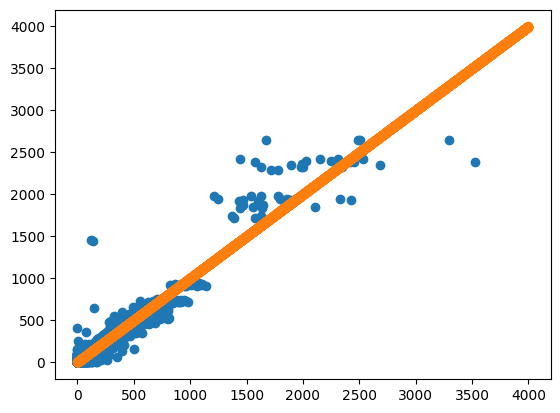

In [91]:
plt.scatter(y_test, preds)
x = np.arange(0, 4000, 1)
plt.scatter(x, x)
plt.show()

In [98]:
features_encoded.groupby('MSOA21CD')['crime_count'].mean().sort_values()

MSOA21CD
E02001015       0.000000
E02001163       0.000000
E02001089       0.000000
E02001263       0.000000
E02001187       0.000000
                ...     
E02006932     749.222222
E02000001     836.333333
E02006875    1005.277778
E02000977    1742.777778
E02000972    2342.194444
Name: crime_count, Length: 7236, dtype: float64

In [94]:
features_encoded[features_encoded['crime_count'] > 2500]

,MSOA21CD,month,crime_count,Shape__Area,population,year_int,month_int,month_sin,month_cos,crime_count_lag_1m,crime_count_lag_3m,crime_count_lag_12m,RUC21NM_Larger rural: Further from a major town or city,RUC21NM_Larger rural: Nearer to a major town or city,RUC21NM_Smaller rural: Further from a major town or city,RUC21NM_Smaller rural: Nearer to a major town or city,RUC21NM_Urban: Further from a major town or city,RUC21NM_Urban: Nearer to a major town or city
33126,E02000972,2023-10,2573,1.358305e+06,7948,2023,0,-0.500000,8.660254e-01,2076.0,2355.0,NaN,False,False,False,False,False,True
33127,E02000972,2023-11,3561,1.358305e+06,7948,2023,1,0.000000,1.000000e+00,2573.0,1943.0,NaN,False,False,False,False,False,True
33128,E02000972,2023-12,3425,1.358305e+06,7948,2023,2,0.500000,8.660254e-01,3561.0,2076.0,NaN,False,False,False,False,False,True
33129,E02000972,2024-01,2864,1.358305e+06,7948,2024,1,0.000000,1.000000e+00,3425.0,2573.0,NaN,False,False,False,False,False,True
33130,E02000972,2024-02,3041,1.358305e+06,7948,2024,2,0.500000,8.660254e-01,2864.0,3561.0,NaN,False,False,False,False,False,True
33131,E02000972,2024-03,2739,1.358305e+06,7948,2024,3,0.866025,5.000000e-01,3041.0,3425.0,NaN,False,False,False,False,False,True
33132,E02000972,2024-04,2536,1.358305e+06,7948,2024,4,1.000000,6.123234e-17,2739.0,2864.0,2070.0,False,False,False,False,False,True
33138,E02000972,2024-10,2685,1.358305e+06,7948,2024,0,-0.500000,8.660254e-01,1987.0,2338.0,2573.0,False,False,False,False,False,True
33139,E02000972,2024-11,3295,1.358305e+06,7948,2024,1,0.000000,1.000000e+00,2685.0,1776.0,3561.0,False,False,False,False,False,True
33140,E02000972,2024-12,3525,1.358305e+06,7948,2024,2,0.500000,8.660254e-01,3295.0,1987.0,3425.0,False,False,False,False,False,True
